In [2]:
from prometheus_pandas import query
import datetime as dt
from zoneinfo import ZoneInfo
import pandas as pd
import matplotlib.pyplot as plt

local_address = "gros-50.nancy.grid5000.fr"
local_port = "30090"
p = query.Prometheus(f"http://admin:prom-operator@{local_address}:{local_port}")    

local_tz = ZoneInfo("Europe/Paris")

def execute_query_range(experiment, metric_query, step, output_filename, plot=False):
    tput_series = []

    print("\nBeginning request execution")
    for label, config in experiment.items():    
        df_metric = p.query_range(
            query=metric_query,
            start=config['start'].isoformat(),
            end=config['end'].isoformat(),
            step=step
        )

        tput_series.append(df_metric)

    if tput_series:
        combined_df = pd.concat(tput_series, axis=1)
        combined_df.to_csv(output_filename, index_label='Time')
        print(f"\nFile saved : '{output_filename}'")
        if plot:
            plt.figure(figsize=(12, 8))
            ax = combined_df.boxplot(grid=True, patch_artist=True)
            plt.title(metric_query)
            plt.show()
    else:
        print("\nRequest Error")

### Experiment 1a

In [3]:
experiment_1k = {
    'rocks': {
        'start': dt.datetime(2025, 8, 25, 11, 11, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 8, 25, 11, 21, 0, tzinfo=local_tz)
    },
    'forst': {
        'start': dt.datetime(2025, 8, 25, 11, 24, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 8, 25, 11, 34, 0, tzinfo=local_tz)
    },
    'forst (128-1)': {
        'start': dt.datetime(2025, 8, 25, 11, 38, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 8, 25, 11, 48, 0, tzinfo=local_tz)
    },
    'forst_no_cache': {
        'start': dt.datetime(2025, 8, 25, 11, 53, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 8, 25, 12, 1, 0, tzinfo=local_tz)
    }
}

experiment_10k = {
    'rocks': {
        'start': dt.datetime(2025, 8, 25, 12, 4, 30, tzinfo=local_tz),
        'end': dt.datetime(2025, 8, 25, 12, 14, 30, tzinfo=local_tz)
    },
    'forst': {
        'start': dt.datetime(2025, 8, 27, 15, 31, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 8, 27, 15, 41, 0, tzinfo=local_tz)
    },
    'forst (128 - 1)': {
        'start': dt.datetime(2025, 8, 25, 13, 40, 30, tzinfo=local_tz),
        'end': dt.datetime(2025, 8, 25, 13, 50, 30, tzinfo=local_tz)
    }
}

### TPUT Measurement

In [4]:
metric_query = 'sum(rate(flink_taskmanager_job_task_operator_numRecordsOut{operator_name=~"Source:.*"}[1m]))'
step = "5s"
output_filename = 'exp1a_10k_tput.csv'
execute_query_range(experiment_10k, metric_query, step, output_filename)

metric_query = 'flink_taskmanager_Status_JVM_CPU_Load{component="taskmanager"}'
step = "5s"
output_filename = 'exp1a_10k_cpu_load.csv'
execute_query_range(experiment_10k, metric_query, step, output_filename)

metric_query = 'flink_jobmanager_job_lastCheckpointDuration{component="jobmanager"}'
step = "30s"
output_filename = 'exp1a_10k_cp_time.csv'
execute_query_range(experiment_10k, metric_query, step, output_filename)

metric_query = 'sum(rate(container_network_receive_bytes_total{namespace="minio-tenant", pod=~"myminio-.*"}[2m]))'
step = "5s"
output_filename = 'exp1a_10k_minio_bytes_receive.csv'
execute_query_range(experiment_10k, metric_query, step, output_filename)

metric_query = 'sum(rate(container_network_transmit_bytes_total{namespace="minio-tenant", pod=~"myminio-.*"}[2m]))'
step = "5s"
output_filename = 'exp1a_10k_minio_bytes_send.csv'
execute_query_range(experiment_10k, metric_query, step, output_filename)

metric_query = 'sum(flink_taskmanager_job_task_operator_column_family_rocksdb_total_sst_files_size{component="taskmanager"})'
step = "5s"
output_filename = 'exp1a_10k_sst_size.csv'
execute_query_range(experiment_10k, metric_query, step, output_filename)

metric_query = 'sum(rate(container_network_transmit_bytes_total{node="gros-96.nancy.grid5000.fr"}[2m]))'
step = "5s"
output_filename = 'exp1a_10k_tm_bytes_send.csv'
execute_query_range(experiment_10k, metric_query, step, output_filename)

metric_query = 'sum(rate(container_network_receive_bytes_total{node="gros-96.nancy.grid5000.fr"}[2m]))'
step = "5s"
output_filename = 'exp1a_10k_tm_bytes_received.csv'
execute_query_range(experiment_10k, metric_query, step, output_filename)

metric_query = 'flink_jobmanager_job_lastCheckpointSize{component="jobmanager"}'
step = "30s"
output_filename = 'exp1a_10k_cp_size.csv'
execute_query_range(experiment_10k, metric_query, step, output_filename)

metric_query = 'sum(rate(flink_taskmanager_job_task_operator_rocksdb_block_cache_hit{component="taskmanager"}[2m]))/(sum(rate(flink_taskmanager_job_task_operator_rocksdb_block_cache_miss{component="taskmanager"}[2m]))+sum(rate(flink_taskmanager_job_task_operator_rocksdb_block_cache_hit{component="taskmanager"}[2m])))'
step = "5s"
output_filename = 'exp1a_10k_cache_hit_ratio.csv'
execute_query_range(experiment_10k, metric_query, step, output_filename)

metric_query = 'rate(minio_bucket_traffic_received_bytes{job="minio"}[2m])'
step = "1m"
output_filename = 'exp1a_10k_bucket_received_bytes_rate.csv'
execute_query_range(experiment_10k, metric_query, step, output_filename)

metric_query = 'rate(minio_node_io_rchar_bytes{job=~"minio"}[2m])'
step = "1m"
output_filename = 'exp1a_10k_read_bytes_rate.csv'
execute_query_range(experiment_10k, metric_query, step, output_filename)

metric_query = 'rate(minio_node_io_wchar_bytes{job=~"minio"}[2m])'
step = "1m"
output_filename = 'exp1a_10k_write_bytes_rate.csv'
execute_query_range(experiment_10k, metric_query, step, output_filename)

metric_query = 'sum(minio_node_drive_used_bytes{job=~"minio"})'
step = "1m"
output_filename = 'exp1a_10k_drive_used_bytes.csv'
execute_query_range(experiment_10k, metric_query, step, output_filename)

metric_query = 'sum by (api) (minio_node_drive_latency_us{job=~"minio"})'
step = "1m"
output_filename = 'exp1a_10k_operation_latency.csv'
execute_query_range(experiment_10k, metric_query, step, output_filename)

metric_query = '(increase(minio_bucket_requests_total{job="minio"}[2m]))'
step = "1m"
output_filename = 'exp1a_10k_operation_request_rate.csv' #type of operation (create/get/delete/... and its rate)
execute_query_range(experiment_10k, metric_query, step, output_filename)


Beginning request execution

File saved : 'exp1a_10k_tput.csv'

Beginning request execution

File saved : 'exp1a_10k_cpu_load.csv'

Beginning request execution

File saved : 'exp1a_10k_cp_time.csv'

Beginning request execution

File saved : 'exp1a_10k_minio_bytes_receive.csv'

Beginning request execution

File saved : 'exp1a_10k_minio_bytes_send.csv'

Beginning request execution

File saved : 'exp1a_10k_sst_size.csv'

Beginning request execution

File saved : 'exp1a_10k_tm_bytes_send.csv'

Beginning request execution

File saved : 'exp1a_10k_tm_bytes_received.csv'

Beginning request execution

File saved : 'exp1a_10k_cp_size.csv'

Beginning request execution

File saved : 'exp1a_10k_cache_hit_ratio.csv'

Beginning request execution

File saved : 'exp1a_10k_bucket_received_bytes_rate.csv'

Beginning request execution

File saved : 'exp1a_10k_read_bytes_rate.csv'

Beginning request execution

File saved : 'exp1a_10k_write_bytes_rate.csv'

Beginning request execution

File saved : 'exp1a

### CPU Load

In [4]:
metric_query = 'flink_taskmanager_Status_JVM_CPU_Load{component="taskmanager"}'
step = "5s"
output_filename = 'xp1results/1ktput/exp1a_1k_cpu_load.csv'

execute_query_range(experiments, metric_query, step, output_filename)

NameError: name 'experiments' is not defined

### Chepointing time

In [ ]:
metric_query = 'flink_jobmanager_job_lastCheckpointDuration{component="jobmanager"}'
step = "30s"
output_filename = 'xp1results/1ktput/exp1a_1k_cp_time.csv'

execute_query_range(experiments, metric_query, step, output_filename)


Beginning request execution

File saved : 'xp1results/1ktput/exp1a_1k_cp_time.csv'


### Boxplot from file

<Figure size 390x260 with 0 Axes>

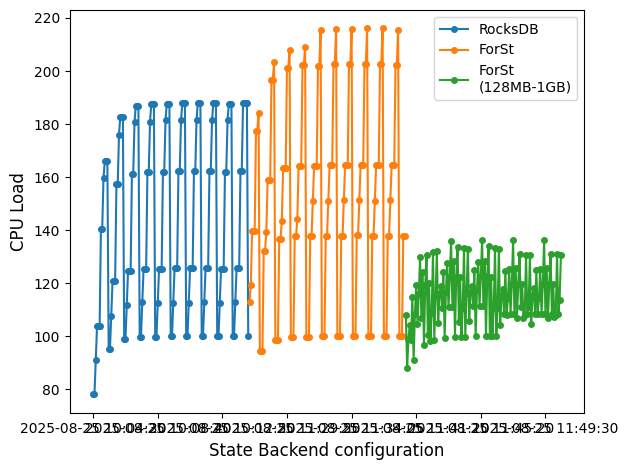

In [7]:
file_path = '10ktput/exp1a_10k_sst_size.csv'

try:
    df = pd.read_csv(file_path, index_col=0)
    df = df / (1024 * 1024)
    df.columns = ['RocksDB', 'ForSt', 'ForSt\n(128MB-1GB)']#, 'ForSt\n(no cache)']
    
    plt.figure(figsize=(3*1.3,2*1.3))
    #df.boxplot(grid=True, patch_artist=True)
    df.plot(style='-o', markersize=4)
    plt.ylabel('CPU Load', fontsize=12)
    plt.xlabel('State Backend configuration', fontsize=12)
    #plt.ylim(0,1)
    plt.tight_layout()
    plt.savefig('10ktput/boxplot_10k_sst_size.pdf')
    plt.show()
    
except FileNotFoundError:
    print(f"Le fichier '{file_path}' est introuvable.")
except Exception as e:
    print(f"Une erreur est survenue : {e}")

Le graphique a été sauvegardé sous 'exp2c_q3_rocksdb_operations.png'


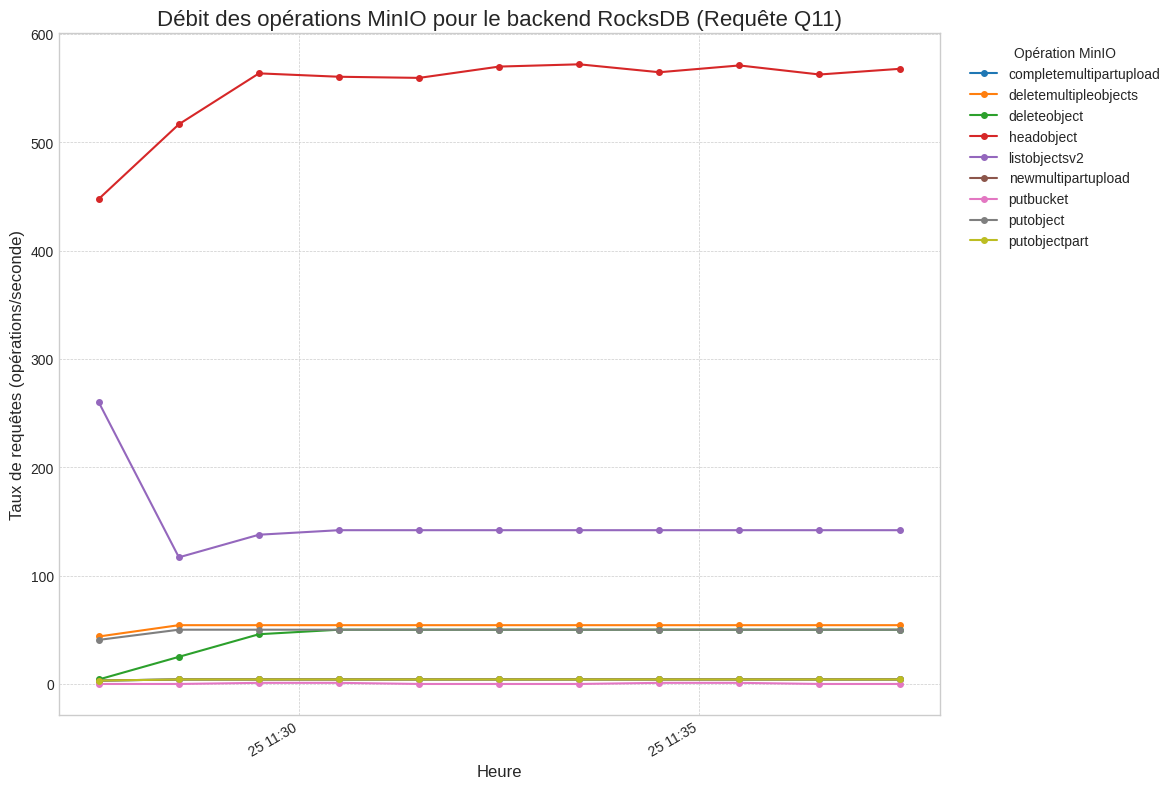

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import datetime as dt
from zoneinfo import ZoneInfo

def plot_rocksdb_operations(csv_file, start_time, end_time):
    """
    Charge les données de débit des opérations MinIO, filtre pour l'expérience RocksDB
    et génère un graphique.
    """
    try:
        df = pd.read_csv(csv_file, index_col='Time', parse_dates=True)

        # Localiser l'index pour le rendre "aware"
        try:
            df.index = df.index.tz_localize('Europe/Paris')
        except TypeError:
            # Gère le cas où l'index est déjà localisé
            df.index = df.index.tz_convert('Europe/Paris')

        # --- ASTUCE DE DÉBOGAGE ---
        # print("Plage horaire réelle du fichier :")
        # print(f"Début : {df.index.min()}")
        # print(f"Fin   : {df.index.max()}")
        
        def clean_col_name(col_name):
            match = re.search(r'api="([^"]+)"', col_name)
            return match.group(1) if match else col_name
        df.columns = [clean_col_name(col) for col in df.columns]

        rocks_df = df.loc[start_time:end_time].copy()

        if rocks_df.empty:
            print("Aucune donnée trouvée pour la période spécifiée. Vérifiez les dates.")
            return

        active_operations_df = rocks_df.loc[:, (rocks_df.sum(numeric_only=True) > 0)]

        if active_operations_df.empty:
            print("Aucune opération avec un débit > 0 n'a été trouvée.")
            return

        plt.style.use('seaborn-v0_8-whitegrid')
        fig, ax = plt.subplots(figsize=(14, 8))
        active_operations_df.plot(ax=ax, style='-o', markersize=4)
        #active_operations_df.plot(ax=ax, stacked=True)
        """
# --- MODIFICATION : Utilisation de ax.stackplot() ---
        # Préparer les données pour la fonction
        x_data = active_operations_df.index
        # .stackplot attend une séquence de tableaux 1D, on transpose le DataFrame
        y_data = active_operations_df.T.values 
        labels = active_operations_df.columns

        # Créer le graphique en aires empilées
        ax.stackplot(x_data, y_data, labels=labels)
        """
        ax.set_title('Débit des opérations MinIO pour le backend RocksDB (Requête Q11)', fontsize=16)
        ax.set_xlabel('Heure', fontsize=12)
        ax.set_ylabel('Taux de requêtes (opérations/seconde)', fontsize=12)
        ax.legend(title='Opération MinIO', bbox_to_anchor=(1.02, 1), loc='upper left')
        ax.grid(True, which='both', linestyle='--', linewidth=0.5)
        
        plt.tight_layout(rect=[0, 0, 0.85, 1])
        plt.savefig('10ktput/exp1a_10k_operation_tmp.pdf')
        print("Le graphique a été sauvegardé sous 'exp2c_q3_rocksdb_operations.png'")
        plt.show()

    except FileNotFoundError:
        print(f"Le fichier '{csv_file}' est introuvable.")
    except Exception as e:
        print(f"Une erreur est survenue : {e}")


# --- Utilisation avec les heures corrigées ---
local_tz = ZoneInfo("Europe/Paris")

# On utilise maintenant la plage horaire de 13h, qui correspond aux données du fichier
rocksdb_start_corrected = dt.datetime(2025, 8, 25, 11, 27, 30, tzinfo=local_tz)
rocksdb_end_corrected = dt.datetime(2025, 8, 25, 11, 37, 30, tzinfo=local_tz)
csv_filename = '10ktput/exp1a_10k_operation_request_rate.csv'

plot_rocksdb_operations(csv_filename, rocksdb_start_corrected, rocksdb_end_corrected)

Le graphique a été sauvegardé sous '1ktput/exp1a_1k_operation_request_rate_boxplot_filled.pdf'


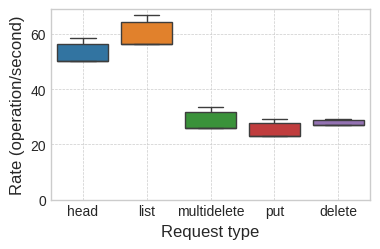

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import datetime as dt
from zoneinfo import ZoneInfo
import seaborn as sns # On utilise Seaborn pour le tracé

def plot_rocksdb_operations_boxplot(csv_file, start_time, end_time):
    """
    Charge les données de débit des opérations MinIO, filtre pour l'expérience RocksDB
    et pour des colonnes spécifiques, puis génère un boxplot avec des boîtes pleines.
    """
    try:
        df = pd.read_csv(csv_file, index_col='Time', parse_dates=True)

        # Localiser l'index
        try:
            df.index = df.index.tz_localize('Europe/Paris')
        except TypeError:
            df.index = df.index.tz_convert('Europe/Paris')

        def clean_col_name(col_name):
            match = re.search(r'api="([^"]+)"', col_name)
            return match.group(1) if match else col_name
        df.columns = [clean_col_name(col) for col in df.columns]

        rocks_df = df.loc[start_time:end_time].copy()

        # On ne garde que les colonnes spécifiées
        columns_to_keep = [
            'headobject',
            'listobjectsv2',
            'deletemultipleobjects',
            'putobject',
                        'deleteobject',

        ]
        existing_columns = [col for col in columns_to_keep if col in rocks_df.columns]
        
        if not existing_columns:
            print("Aucune des colonnes spécifiées n'a été trouvée dans les données.")
            return
            
        rocks_df = rocks_df[existing_columns]

        if rocks_df.empty:
            print("Aucune donnée trouvée pour la période spécifiée.")
            return

        active_operations_df = rocks_df.loc[:, (rocks_df.sum(numeric_only=True) > 0)]

        if active_operations_df.empty:
            print("Aucune opération avec un débit > 0 n'a été trouvée pour les colonnes sélectionnées.")
            return
        new_axis_labels = {
            'deleteobject': 'delete',
            'headobject': 'head',
            'listobjectsv2': 'list',
            'deletemultipleobjects': 'multidelete',
            'putobject': 'put',
            
        }
        active_operations_df = active_operations_df.rename(columns=new_axis_labels)
        # --- MODIFICATION : Utilisation de Seaborn pour un boxplot plein ---
        plt.style.use('seaborn-v0_8-whitegrid')
        fig, ax = plt.subplots(figsize=(3*1.3,2*1.3))
        
        # On remplace la fonction de Pandas par celle de Seaborn
        # qui crée des boîtes pleines par défaut.
        sns.boxplot(data=active_operations_df, ax=ax)
        ax.set_xlabel('Request type', fontsize=12)
        ax.set_ylabel('Rate (operation/second)', fontsize=12)
        
        ax.grid(True, which='both', linestyle='--', linewidth=0.5)
        ax.set_ylim(0)
        plt.tight_layout()
        plt.savefig('1ktput/exp1a_1k_operation_request_rate_rocks.pdf')
        print("Le graphique a été sauvegardé sous '1ktput/exp1a_1k_operation_request_rate_boxplot_filled.pdf'")
        plt.show()

    except FileNotFoundError:
        print(f"Le fichier '{csv_file}' est introuvable.")
    except Exception as e:
        print(f"Une erreur est survenue : {e}")


# --- Utilisation ---
local_tz = ZoneInfo("Europe/Paris")

rocksdb_start_corrected = dt.datetime(2025, 8, 25, 9, 1, 00, tzinfo=local_tz)
rocksdb_end_corrected = dt.datetime(2025, 8, 25, 9, 21, 0, tzinfo=local_tz)
csv_filename = '1ktput/exp1a_1k_operation_request_rate.csv'

plot_rocksdb_operations_boxplot(csv_filename, rocksdb_start_corrected, rocksdb_end_corrected)

Le fichier CSV unifié a été sauvegardé sous : '10ktput/checkpoint_metrics_combined.csv'
Le graphique de régression avec Pearson a été sauvegardé sous : '10ktput/checkpoint_regression_with_pearson.pdf'


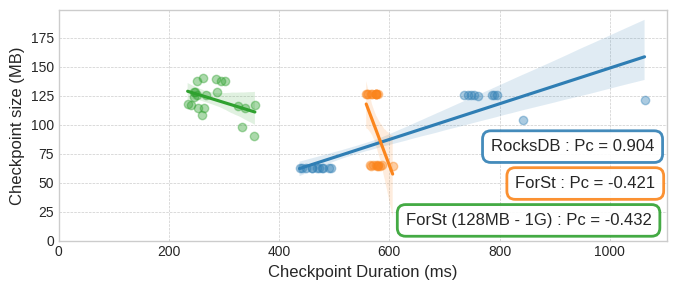

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr # Importation nécessaire pour le calcul

def process_and_plot_regression(time_file, size_file, output_csv, output_plot):
    """
    Combine les données de durée et de taille des checkpoints, crée un CSV unifié
    et génère un graphique de régression linéaire avec le coefficient de Pearson.
    """
    try:
        # 1. Charger et nettoyer les deux fichiers CSV
        df_time = pd.read_csv(time_file, usecols=[0, 1, 2, 3], names=['Time', 'Duration_RocksDB', 'Duration_ForSt', 'D3'], skiprows=1)
        df_size = pd.read_csv(size_file, usecols=[0, 1, 2, 3], names=['Time', 'Size_RocksDB', 'Size_ForSt', 'S3'], skiprows=1)

        df_time['Time'] = pd.to_datetime(df_time['Time'])
        df_size['Time'] = pd.to_datetime(df_size['Time'])

        # 2. Créer des DataFrames séparés pour chaque backend
        rocks_time = df_time[['Time', 'Duration_RocksDB']].dropna().rename(columns={'Duration_RocksDB': 'Duration_ms'})
        rocks_size = df_size[['Time', 'Size_RocksDB']].dropna().rename(columns={'Size_RocksDB': 'Size_B'})
        df_rocks = pd.merge(rocks_time, rocks_size, on='Time')
        df_rocks['Backend'] = 'RocksDB'

        forst_time = df_time[['Time', 'Duration_ForSt']].dropna().rename(columns={'Duration_ForSt': 'Duration_ms'})
        forst_size = df_size[['Time', 'Size_ForSt']].dropna().rename(columns={'Size_ForSt': 'Size_B'})
        df_forst = pd.merge(forst_time, forst_size, on='Time')
        df_forst['Backend'] = 'ForSt'
        
        sforst_time = df_time[['Time', 'D3']].dropna().rename(columns={'D3': 'Duration_ms'})
        sforst_size = df_size[['Time', 'S3']].dropna().rename(columns={'S3': 'Size_B'})
        sdf_forst = pd.merge(sforst_time, sforst_size, on='Time')
        sdf_forst['Backend'] = 'ForSt (128MB - 1G)'


        # 3. Combiner et préparer les données
        combined_df = pd.concat([df_rocks, df_forst, sdf_forst], ignore_index=True)
        combined_df['Size_MB'] = combined_df['Size_B'] / (1024 **2)
        
        final_df_to_save = combined_df[['Time', 'Duration_ms', 'Size_MB', 'Backend']]
        final_df_to_save.to_csv(output_csv, index=False)
        print(f"Le fichier CSV unifié a été sauvegardé sous : '{output_csv}'")
        
        # 4. Créer le graphique de régression
        plt.style.use('seaborn-v0_8-whitegrid')
        fig, ax = plt.subplots(figsize=(7,3))
        
        # Définir les positions du texte pour chaque backend (en coordonnées relatives à l'axe)
        text_positions = {'RocksDB': (0.71, 0.44), 'ForSt': (0.75, 0.28), 'ForSt (128MB - 1G)': (0.57,0.12)}

        for backend, color in [('RocksDB', '#2f7eb4'), ('ForSt', '#fb851c'), ('ForSt (128MB - 1G)', '#2fa12f')]:
            backend_data = combined_df[combined_df['Backend'] == backend]
            
            sns.regplot(
                data=backend_data,
                x='Duration_ms',
                y='Size_MB',
                ax=ax,
                label=backend,
                color=color,
                scatter_kws={'alpha': 0.4}
            )
            
            # --- MODIFICATION : Calculer et afficher le coefficient de Pearson ---
            # S'assurer qu'il y a assez de données pour le calcul
            if len(backend_data) > 1:
                corr, _ = pearsonr(backend_data['Duration_ms'], backend_data['Size_MB'])
                
                # Définir le texte à afficher
                text_str = f"{backend} : Pc = {corr:.3f}"
                
                # Définir le style de la boîte
                box_props = dict(boxstyle='round,pad=0.5', fc='white', ec=color, lw=2, alpha=0.9)
                
                # Ajouter le texte encadré sur le graphique
                pos_x, pos_y = text_positions[backend]
                ax.text(pos_x, pos_y, text_str, transform=ax.transAxes, fontsize=12,
                        verticalalignment='top', bbox=box_props)
            # --------------------------------------------------------------------

        ax.set_xlabel('Checkpoint Duration (ms)', fontsize=12)
        ax.set_ylabel('Checkpoint size (MB)',fontsize=12)
        ax.set_ylim(0)
        ax.set_xlim(0)
        #ax.legend()
        ax.grid(True, which='both', linestyle='--', linewidth=0.5)
        plt.tight_layout()
        plt.savefig(output_plot)
        print(f"Le graphique de régression avec Pearson a été sauvegardé sous : '{output_plot}'")
        plt.show()

    except FileNotFoundError as e:
        print(f"Erreur : Fichier introuvable. Assurez-vous que '{e.filename}' est dans le bon dossier.")
    except Exception as e:
        print(f"Une erreur est survenue : {e}")

# --- Utilisation du script ---
time_csv = '10ktput/exp1a_10k_cp_time.csv'
size_csv = '10ktput/exp1a_10k_cp_size.csv'
output_csv_filename = '10ktput/checkpoint_metrics_combined.csv'
output_plot_filename = '10ktput/checkpoint_regression_with_pearson.pdf'

process_and_plot_regression(time_csv, size_csv, output_csv_filename, output_plot_filename)